In [ ]:
import pandas as pd
import numpy as np
from numpy import array
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [ ]:
df = pd.read_csv("apple_share_price.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,11-Aug-17,156.60,158.57,156.07,157.48,26257096
1,10-Aug-17,159.90,160.00,154.63,155.32,40804273
2,9-Aug-17,159.26,161.27,159.11,161.06,26131530
3,8-Aug-17,158.60,161.83,158.27,160.08,36205896
4,7-Aug-17,157.06,158.92,156.67,158.81,21870321


In [ ]:
df.shape

(1664, 6)

In [ ]:
df1 = df.reset_index()['Close']
df1

,Close
0,157.48
1,155.32
2,161.06
3,160.08
4,158.81
...,...
1659,48.02
1660,47.68
1661,47.71
1662,47.33


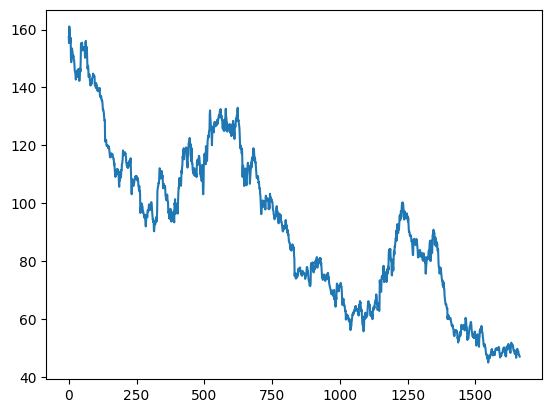

In [ ]:
plt.plot(df1)
plt.show()

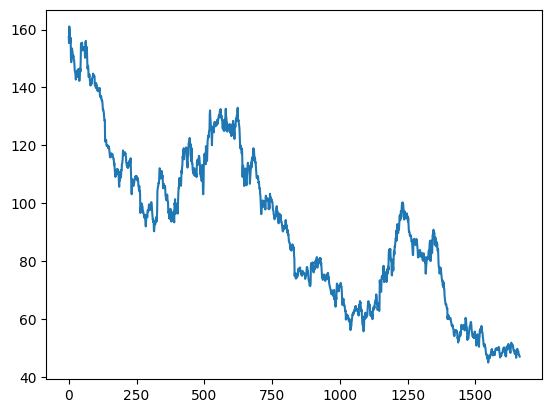

In [ ]:
df1 = df.reset_index()['Close']
plt.plot(df1)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
df1 = scaler.fit_transform(np.array(df1).reshape(-1,1))
df1

array([[0.96914059],
       [0.95052151],
       [1.        ],
       ...,
       [0.02292906],
       [0.01965348],
       [0.01749849]])

In [ ]:
training_size = int(len(df1)*0.65)
test_size = len(df1) - training_size

train_data, test_data = df1[0:training_size,:], df1[training_size:len(df1),:1]

print(training_size, test_size)

1081 583


In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
time_step = 100

X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(ytest.shape)

(980, 100)
(980,)
(482, 100)
(482,)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(980, 100, 1)
(482, 100, 1)


In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, validation_data=(X_test, ytest), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - loss: 0.1169 - val_loss: 0.0057
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - loss: 0.0121 - val_loss: 0.0080
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - loss: 0.0015 - val_loss: 9.9690e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - loss: 0.0015 - val_loss: 9.9380e-04
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - loss: 0.0014 - val_loss: 9.5818e-04
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 0.0014 - val_loss: 9.1296e-04
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - loss: 0.0012 - val_loss: 8.7950e-04
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.0013 - val_loss: 8.8173e-04
Epoch 12/100
16/1

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [ ]:
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [ ]:
y_train = scaler.inverse_transform(y_train.reshape(-1,1))
ytest = scaler.inverse_transform(ytest.reshape(-1,1))

In [ ]:
import math
from sklearn.metrics import mean_squared_error

print("Train RMSE:", math.sqrt(mean_squared_error(y_train, train_predict)))
print("Test RMSE:", math.sqrt(mean_squared_error(ytest, test_predict)))

Train RMSE: 2.2742868995249452
Test RMSE: 2.082223396847193


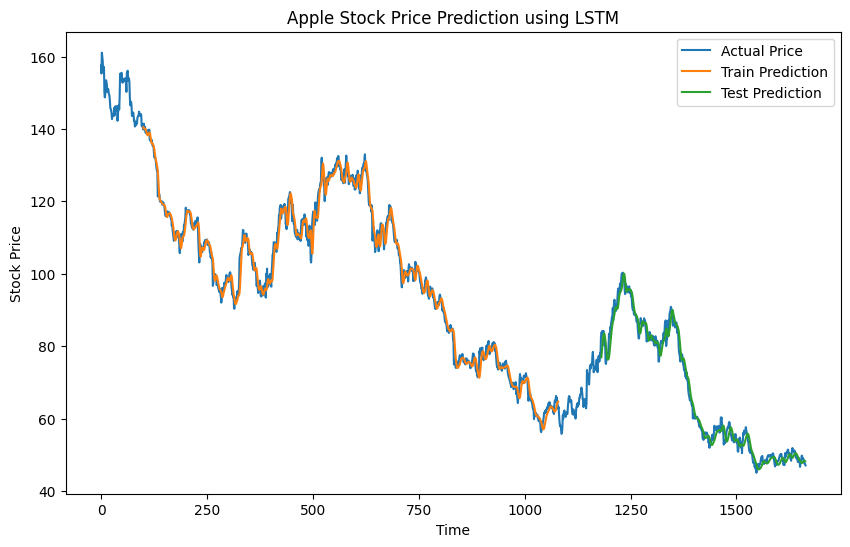

In [ ]:
# shift train predictions for plotting
look_back = 100
trainPredictPlot = np.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

# shift test predictions for plotting
testPredictPlot = np.empty_like(df1)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict

# plot baseline and predictions
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(df1), label="Actual Price")
plt.plot(trainPredictPlot, label="Train Prediction")
plt.plot(testPredictPlot, label="Test Prediction")

plt.title("Apple Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
x_input = test_data[len(test_data)-100:].reshape(1,-1)
x_input.shape

(1, 100)

In [ ]:
temp_input = list(x_input)
temp_input = temp_input[0].tolist()

from numpy import array

lst_output = []
n_steps = 100
i = 0

while(i < 30):

    if(len(temp_input) > 100):
        x_input = np.array(temp_input[1:])
        x_input = x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))

        yhat = model.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        temp_input = temp_input[1:]

        lst_output.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)

        temp_input.extend(yhat[0].tolist())
        lst_output.extend(yhat.tolist())
        i = i + 1

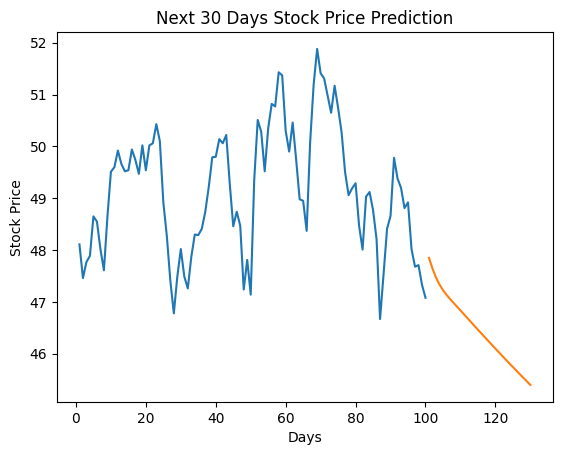

In [ ]:
day_new = np.arange(1,101)
day_pred = np.arange(101,131)

plt.plot(day_new, scaler.inverse_transform(df1[-100:]))
plt.plot(day_pred, scaler.inverse_transform(lst_output))
plt.title("Next 30 Days Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.show()

In [ ]:
model.save("lstm_stock_model.h5")

In [1]:
import pandas as pd

news = pd.read_csv("RedditNews.csv")

news.head()

,Date,News
0,2016-07-01,A 117-year-old woman in Mexico City finally re...
1,2016-07-01,IMF chief backs Athens as permanent Olympic host
2,2016-07-01,"The president of France says if Brexit won, so..."
3,2016-07-01,British Man Who Must Give Police 24 Hours' Not...
4,2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...


In [2]:
news.rename(columns={"News":"headline"}, inplace=True)

news.head()

,Date,headline
0,2016-07-01,A 117-year-old woman in Mexico City finally re...
1,2016-07-01,IMF chief backs Athens as permanent Olympic host
2,2016-07-01,"The president of France says if Brexit won, so..."
3,2016-07-01,British Man Who Must Give Police 24 Hours' Not...
4,2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...


In [3]:
import re

def clean_text(text):

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()

    return text

news["clean_headline"] = news["headline"].apply(clean_text)

news.head()

,Date,headline,clean_headline
0,2016-07-01,A 117-year-old woman in Mexico City finally re...,a yearold woman in mexico city finally receive...
1,2016-07-01,IMF chief backs Athens as permanent Olympic host,imf chief backs athens as permanent olympic host
2,2016-07-01,"The president of France says if Brexit won, so...",the president of france says if brexit won so ...
3,2016-07-01,British Man Who Must Give Police 24 Hours' Not...,british man who must give police hours notice...
4,2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...,nobel laureates urge greenpeace to stop opposi...


In [4]:
!pip install nltk

In [6]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def tokenize(text):

    words = word_tokenize(text)

    filtered_words = [w for w in words if w not in stop_words]

    return filtered_words


news["tokens"] = news["clean_headline"].apply(tokenize)

news.head()

,Date,headline,clean_headline,tokens
0,2016-07-01,A 117-year-old woman in Mexico City finally re...,a yearold woman in mexico city finally receive...,"[yearold, woman, mexico, city, finally, receiv..."
1,2016-07-01,IMF chief backs Athens as permanent Olympic host,imf chief backs athens as permanent olympic host,"[imf, chief, backs, athens, permanent, olympic..."
2,2016-07-01,"The president of France says if Brexit won, so...",the president of france says if brexit won so ...,"[president, france, says, brexit, donald, trump]"
3,2016-07-01,British Man Who Must Give Police 24 Hours' Not...,british man who must give police hours notice...,"[british, man, must, give, police, hours, noti..."
4,2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...,nobel laureates urge greenpeace to stop opposi...,"[nobel, laureates, urge, greenpeace, stop, opp..."


In [8]:
from collections import Counter

all_words = []

for tokens in news["tokens"]:
    all_words.extend(tokens)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('us', 6206),
 ('says', 3656),
 ('new', 3490),
 ('police', 2924),
 ('government', 2809),
 ('people', 2788),
 ('china', 2510),
 ('world', 2485),
 ('israel', 2357),
 ('war', 2305),
 ('years', 2213),
 ('killed', 1980),
 ('president', 1967),
 ('one', 1947),
 ('russia', 1924),
 ('uk', 1806),
 ('first', 1797),
 ('said', 1749),
 ('iran', 1687),
 ('state', 1683)]

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

X_text = tfidf.fit_transform(news["clean_headline"])

print(X_text.shape)

(73608, 500)


In [11]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [12]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

news["sentiment_score"] = news["clean_headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

news.head()

,Date,headline,clean_headline,tokens,sentiment_score
0,2016-07-01,A 117-year-old woman in Mexico City finally re...,a yearold woman in mexico city finally receive...,"[yearold, woman, mexico, city, finally, receiv...",-0.5574
1,2016-07-01,IMF chief backs Athens as permanent Olympic host,imf chief backs athens as permanent olympic host,"[imf, chief, backs, athens, permanent, olympic...",-0.0516
2,2016-07-01,"The president of France says if Brexit won, so...",the president of france says if brexit won so ...,"[president, france, says, brexit, donald, trump]",0.5719
3,2016-07-01,British Man Who Must Give Police 24 Hours' Not...,british man who must give police hours notice...,"[british, man, must, give, police, hours, noti...",-0.8658
4,2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...,nobel laureates urge greenpeace to stop opposi...,"[nobel, laureates, urge, greenpeace, stop, opp...",-0.2960


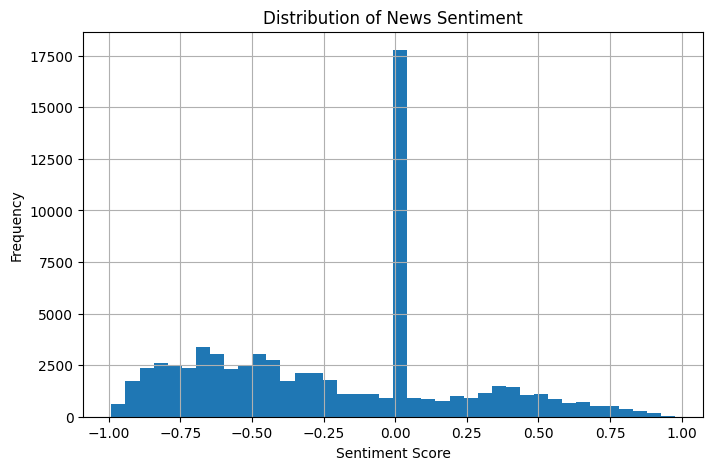

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

news["sentiment_score"].hist(bins=40)

plt.title("Distribution of News Sentiment")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.show()

In [14]:
sentiment_daily = news.groupby("Date")["sentiment_score"].mean()

sentiment_daily.head()

,sentiment_score
Date,
2008-06-08,-0.334284
2008-06-09,-0.276144
2008-06-10,-0.308360
2008-06-11,-0.130976
2008-06-12,-0.106308


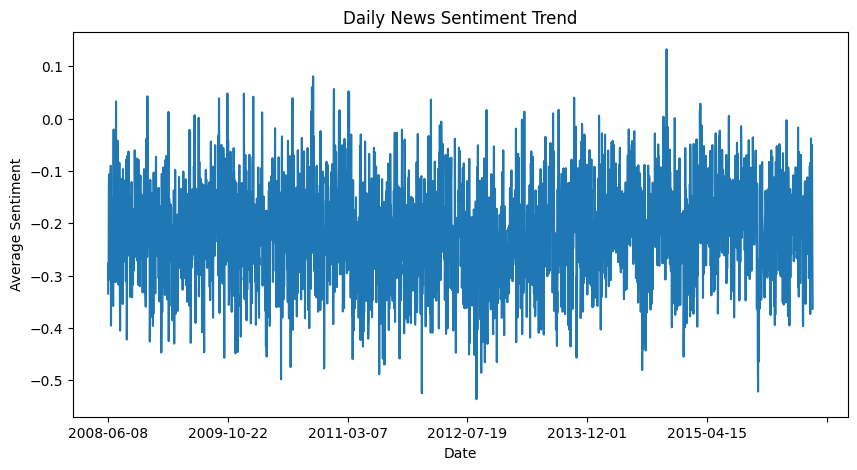

In [15]:
plt.figure(figsize=(10,5))

sentiment_daily.plot()

plt.title("Daily News Sentiment Trend")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")

plt.show()